# ADHD Diagnosis Classification

**Goal:** Classify subjects into 3 diagnostic classes using clinical/demographic features:
- **0** = Healthy (no ADHD)
- **1** = ADHD (combines original DX classes 1 and 2)
- **2** = Other Diagnosis (original DX class 3)

**Pipeline:** EDA → cleaning → label remapping → synthetic-data augmentation of minority
classes → outlier winsorization → SMOTE imbalance handling → 7 candidate models →
best-model selection → metaheuristic hyperparameter tuning (GWO & GA) → final comparison.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, roc_auc_score)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from mealpy import FloatVar, GWO, GA

RANDOM_STATE = 42
sns.set_style('whitegrid')
CLASS_NAMES = {0: 'Healthy', 1: 'Hyper/Impulsive', 2: 'Inattentive'}
classes = [0, 1, 2]

## 1. Load data

In [3]:
cleaned = pd.read_csv('cleaned_data.csv')
synth = pd.read_csv('synthetic_data.csv')
for df in (cleaned, synth):
    df.rename(columns={'Hyper/Impulsive': 'Hyper_Impulsive'}, inplace=True)
print('cleaned_data.csv  shape:', cleaned.shape)
print('synthetic_data.csv shape:', synth.shape)
cleaned.head()

cleaned_data.csv  shape: (532, 11)
synthetic_data.csv shape: (532, 11)


,Gender,Age,Handedness,DX,ADHD Index,Inattentive,Hyper_Impulsive,Verbal IQ,Performance IQ,Full4 IQ,Med Status
0,0.0,10,1.0,0,47.0,55.0,43.0,121.0,119.0,122.0,1
1,0.0,12,1.0,1,90.0,89.0,78.0,122.0,108.0,106.0,1
2,0.0,8,1.0,0,42.0,42.0,43.0,85.0,98.0,89.0,1
3,0.0,10,1.0,0,42.0,49.0,49.0,85.0,86.0,97.0,1
4,0.0,12,1.0,1,87.0,90.0,90.0,89.0,88.0,89.0,1


## 2. Exploratory Data Analysis (original `cleaned_data.csv`)

In [4]:
cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,532.0,0.578947,0.494193,0.000000,0.000000,1.0,1.0,1.0
Age,532.0,11.169173,3.224428,7.000000,9.000000,10.0,13.0,21.0
Handedness,532.0,0.837368,0.299376,-0.200000,0.740000,1.0,1.0,3.0
DX,532.0,0.718045,1.039436,0.000000,0.000000,0.0,1.0,3.0
ADHD Index,532.0,36.549769,28.022766,1.965385,1.965385,42.0,60.0,99.0
Inattentive,532.0,43.943870,24.525684,8.948827,17.000000,44.5,64.0,90.0
Hyper_Impulsive,532.0,42.969460,24.836043,7.960554,15.000000,44.0,62.0,90.0
Verbal IQ,532.0,83.363932,50.105719,-3.184158,80.750000,105.5,116.0,146.0
Performance IQ,532.0,79.849903,50.165867,-6.801980,77.750000,102.0,114.0,139.0
Full4 IQ,532.0,108.327634,14.375310,73.000000,97.750000,108.0,119.0,144.0


In [5]:
print('Missing values per column:')
print(cleaned.isna().sum())
print('\nDuplicate rows:', cleaned.duplicated().sum())
print('\nOriginal DX class counts:')
print(cleaned['DX'].value_counts().sort_index())

Missing values per column:
Gender             0
Age                0
Handedness         0
DX                 0
ADHD Index         0
Inattentive        0
Hyper_Impulsive    0
Verbal IQ          0
Performance IQ     0
Full4 IQ           0
Med Status         0
dtype: int64

Duplicate rows: 13

Original DX class counts:
DX
0    309
1    138
2     11
3     74
Name: count, dtype: int64


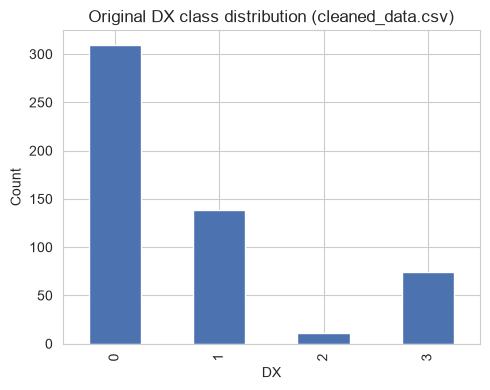

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
cleaned['DX'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Original DX class distribution (cleaned_data.csv)')
ax.set_xlabel('DX'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

The raw label is heavily imbalanced (309 / 138 / 11 / 74 across DX 0–3), with class 2
especially rare (11 subjects). This motivates both the requested label-merging scheme and
the later imbalance handling.

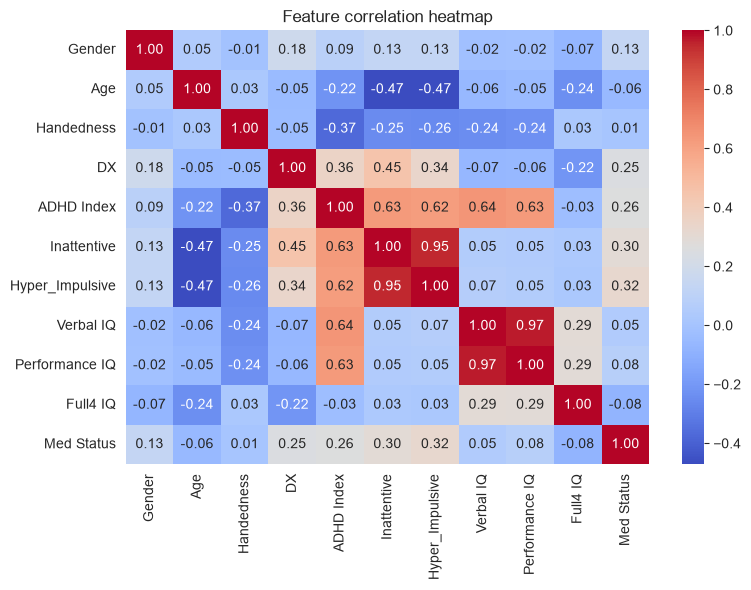

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cleaned.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Feature correlation heatmap')
plt.tight_layout(); plt.show()

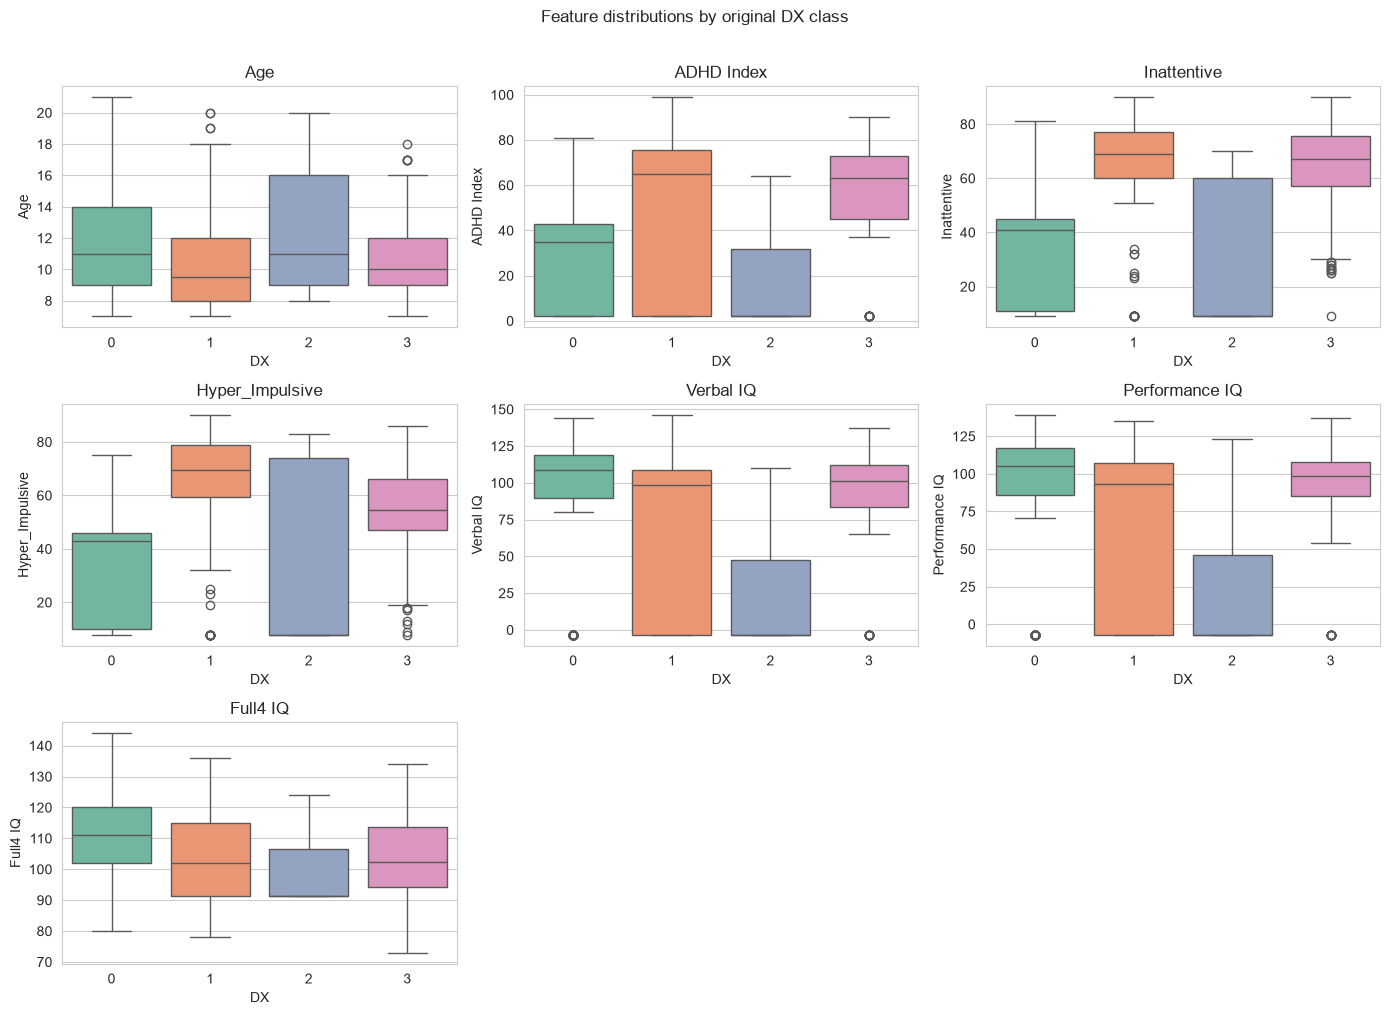

In [8]:
num_feats = ['Age', 'ADHD Index', 'Inattentive', 'Hyper_Impulsive',
             'Verbal IQ', 'Performance IQ', 'Full4 IQ']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, num_feats):
    sns.boxplot(data=cleaned, x='DX', y=col, ax=ax, hue='DX', palette='Set2', legend=False)
    ax.set_title(col)
for ax in axes.flat[len(num_feats):]:
    ax.axis('off')
plt.suptitle('Feature distributions by original DX class', y=1.01)
plt.tight_layout(); plt.show()

### Data-quality finding: sentinel/missing-code values

`Verbal IQ` and `Performance IQ` share an unusual, exactly-repeated minimum value
(`-3.1842` / `-6.8020`) in a large fraction of rows, while `Full4 IQ` remains a plausible,
valid score for those same rows. This is a classic missing-subtest placeholder (common in
ADHD-200-style datasets where only the full-scale IQ was available for some sites/subjects),
**not** a smooth statistical outlier tail — so it needs targeted imputation rather than
blind winsorization.

In [9]:
VIQ_SENT, PIQ_SENT = -3.1841584158415843, -6.801980198019802
n_sent = np.isclose(cleaned['Verbal IQ'], VIQ_SENT, atol=0.05).sum()
print(f'Rows with the Verbal/Performance IQ sentinel code: {n_sent} / {len(cleaned)} ({n_sent/len(cleaned):.1%})')
print('Full4 IQ for those rows is still valid, e.g.:')
print(cleaned.loc[np.isclose(cleaned["Verbal IQ"], VIQ_SENT, atol=0.05), 'Full4 IQ'].describe())

Rows with the Verbal/Performance IQ sentinel code: 127 / 532 (23.9%)
Full4 IQ for those rows is still valid, e.g.:
count    127.000000
mean     105.270090
std       15.530962
min       82.000000
25%       91.297945
50%      102.000000
75%      117.000000
max      144.000000
Name: Full4 IQ, dtype: float64


## 3. Label remapping

Per the requested scheme: DX 0 stays **0** (Healthy); DX 1 & 2 merge into **1** (ADHD);
DX 3 becomes **2** (Other Diagnosis). Applied identically to both files.

In [10]:
def remap_dx(x):
    if x == 0: return 0
    if x in (1, 2): return 1
    if x == 3: return 2
    return np.nan

cleaned['DX_new'] = cleaned['DX'].apply(remap_dx).astype(int)
synth['DX_new'] = synth['DX'].apply(remap_dx).astype(int)
print('cleaned_data.csv remapped class counts:')
print(cleaned['DX_new'].value_counts().sort_index())
print('\nsynthetic_data.csv remapped class counts:')
print(synth['DX_new'].value_counts().sort_index())

cleaned_data.csv remapped class counts:
DX_new
0    309
1    149
2     74
Name: count, dtype: int64

synthetic_data.csv remapped class counts:
DX_new
0    309
1    149
2     74
Name: count, dtype: int64


## 4. Augment minority classes with synthetic data

`synthetic_data.csv` mirrors the same class structure as `cleaned_data.csv`. As requested,
we use it **only** to add extra samples for the minority classes (new class 1 = ADHD, new
class 2 = Other Diagnosis); the majority class (0 = Healthy) is kept as-is from the real data.

In [11]:
synth_minority = synth[synth['DX_new'].isin([1, 2])].copy()
merged = pd.concat([cleaned.drop(columns=['DX']), synth_minority.drop(columns=['DX'])], ignore_index=True)
merged.rename(columns={'DX_new': 'DX'}, inplace=True)
print('Merged (augmented) dataset shape:', merged.shape)
print(merged['DX'].value_counts().sort_index())

Merged (augmented) dataset shape: (755, 11)
DX
0    309
1    298
2    148
Name: count, dtype: int64


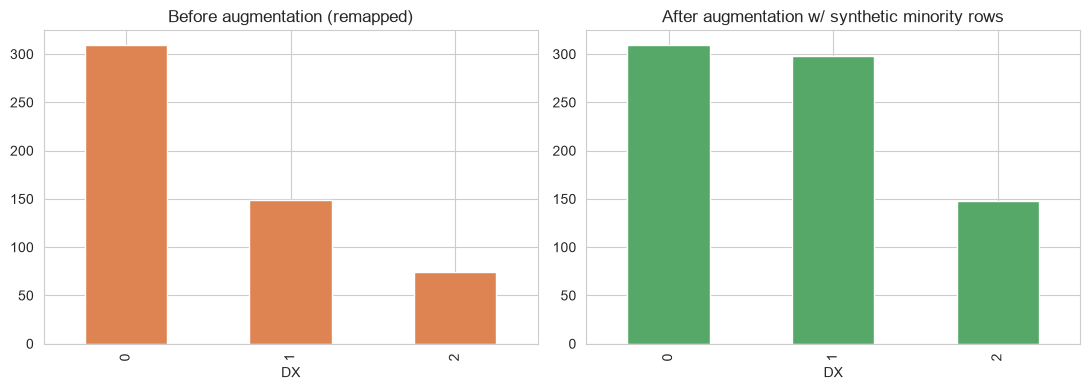

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
cleaned['DX_new'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#DD8452')
ax[0].set_title('Before augmentation (remapped)'); ax[0].set_xlabel('DX')
merged['DX'].value_counts().sort_index().plot(kind='bar', ax=ax[1], color='#55A868')
ax[1].set_title('After augmentation w/ synthetic minority rows'); ax[1].set_xlabel('DX')
plt.tight_layout(); plt.show()

## 5. Data cleaning
- Drop exact duplicate rows.
- Flag the Verbal/Performance IQ sentinel values as missing (`NaN`) so they can be
  properly imputed rather than treated as genuine low scores.

In [83]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 739 entries, 0 to 738
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           739 non-null    float64
 1   Age              739 non-null    int64  
 2   Handedness       739 non-null    float64
 3   ADHD Index       739 non-null    float64
 4   Inattentive      739 non-null    float64
 5   Hyper_Impulsive  739 non-null    float64
 6   Verbal IQ        608 non-null    float64
 7   Performance IQ   609 non-null    float64
 8   Full4 IQ         739 non-null    float64
 9   Med Status       739 non-null    int64  
 10  DX               739 non-null    int64  
dtypes: float64(8), int64(3)
memory usage: 63.6 KB


In [85]:
merged['Med Status'].value_counts()

Med Status
1    610
2    129
Name: count, dtype: int64

In [13]:
before = merged.shape[0]
merged = merged.drop_duplicates().reset_index(drop=True)
print(f'Dropped {before - merged.shape[0]} duplicate rows after merge.')

for col, sent in [('Verbal IQ', VIQ_SENT), ('Performance IQ', PIQ_SENT)]:
    mask = np.isclose(merged[col], sent, atol=0.05)
    merged.loc[mask, col] = np.nan
print('Sentinel-flagged (now missing) values:')
print(merged[['Verbal IQ', 'Performance IQ']].isna().sum())

feature_cols = ['Gender', 'Age', 'Handedness', 'ADHD Index', 'Inattentive', 'Hyper_Impulsive',
                'Verbal IQ', 'Performance IQ', 'Full4 IQ', 'Med Status']
X = merged[feature_cols].copy()
y = merged['DX'].copy()

Dropped 16 duplicate rows after merge.
Sentinel-flagged (now missing) values:
Verbal IQ         131
Performance IQ    130
dtype: int64


## 6. Train / test split

Split **before** fitting any imputer, winsorizer, scaler, or resampler, so that no
information from the test set leaks into preprocessing.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('\nTrain class distribution:'); print(y_train.value_counts().sort_index())
print('\nTest class distribution:'); print(y_test.value_counts().sort_index())

Train shape: (591, 10) | Test shape: (148, 10)

Train class distribution:
DX
0    241
1    232
2    118
Name: count, dtype: int64

Test class distribution:
DX
0    60
1    58
2    30
Name: count, dtype: int64


## 7. Imputation of the sentinel-missing IQ subtests

`Verbal IQ` and `Performance IQ` are imputed from `Full4 IQ` via a simple linear
regression **fit on the training set only**, then applied to both train and test.

In [15]:
def fit_impute(train_df, test_df, target_col, predictor_col='Full4 IQ'):
    train_df = train_df.copy(); test_df = test_df.copy()
    mask_tr = train_df[target_col].notna()
    lr = LinearRegression().fit(train_df.loc[mask_tr, [predictor_col]], train_df.loc[mask_tr, target_col])
    for df in (train_df, test_df):
        mask = df[target_col].isna()
        if mask.any():
            df.loc[mask, target_col] = lr.predict(df.loc[mask, [predictor_col]])
    return train_df, test_df, lr

for col in ['Verbal IQ', 'Performance IQ']:
    X_train, X_test, lr_model = fit_impute(X_train, X_test, col)
    r2 = lr_model.score(X_train[['Full4 IQ']], X_train[col])
    print(f'Imputed {col} from Full4 IQ (train R^2 = {r2:.3f})')

print('\nRemaining NaNs -> train:', X_train.isna().sum().sum(), '| test:', X_test.isna().sum().sum())

Imputed Verbal IQ from Full4 IQ (train R^2 = 0.307)
Imputed Performance IQ from Full4 IQ (train R^2 = 0.289)

Remaining NaNs -> train: 0 | test: 0


## 8. Winsorization (outlier handling)

After the sentinel values have been properly imputed, we cap the remaining genuine tail
outliers at the 1st/99th percentile, with bounds **fit on the training set only**.

In [16]:
winsor_cols = ['ADHD Index', 'Inattentive', 'Hyper_Impulsive', 'Verbal IQ',
               'Performance IQ', 'Full4 IQ', 'Age', 'Handedness']
lower_q, upper_q = 0.01, 0.99
bounds = {col: (X_train[col].quantile(lower_q), X_train[col].quantile(upper_q)) for col in winsor_cols}

def apply_winsor(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        df[col] = df[col].clip(lower=lo, upper=hi)
    return df

X_train_w = apply_winsor(X_train, bounds)
X_test_w = apply_winsor(X_test, bounds)

print('Winsorization bounds (1%-99% of TRAIN, post-imputation):')
for col, (lo, hi) in bounds.items():
    print(f'  {col:18s}: [{lo:8.2f}, {hi:8.2f}]')

Winsorization bounds (1%-99% of TRAIN, post-imputation):
  ADHD Index        : [    1.97,    99.00]
  Inattentive       : [    8.95,    90.00]
  Hyper_Impulsive   : [    7.96,    90.00]
  Verbal IQ         : [    9.86,   146.00]
  Performance IQ    : [    6.42,   139.00]
  Full4 IQ          : [   73.00,   140.00]
  Age               : [    7.00,    19.00]
  Handedness        : [   -0.00,     1.40]


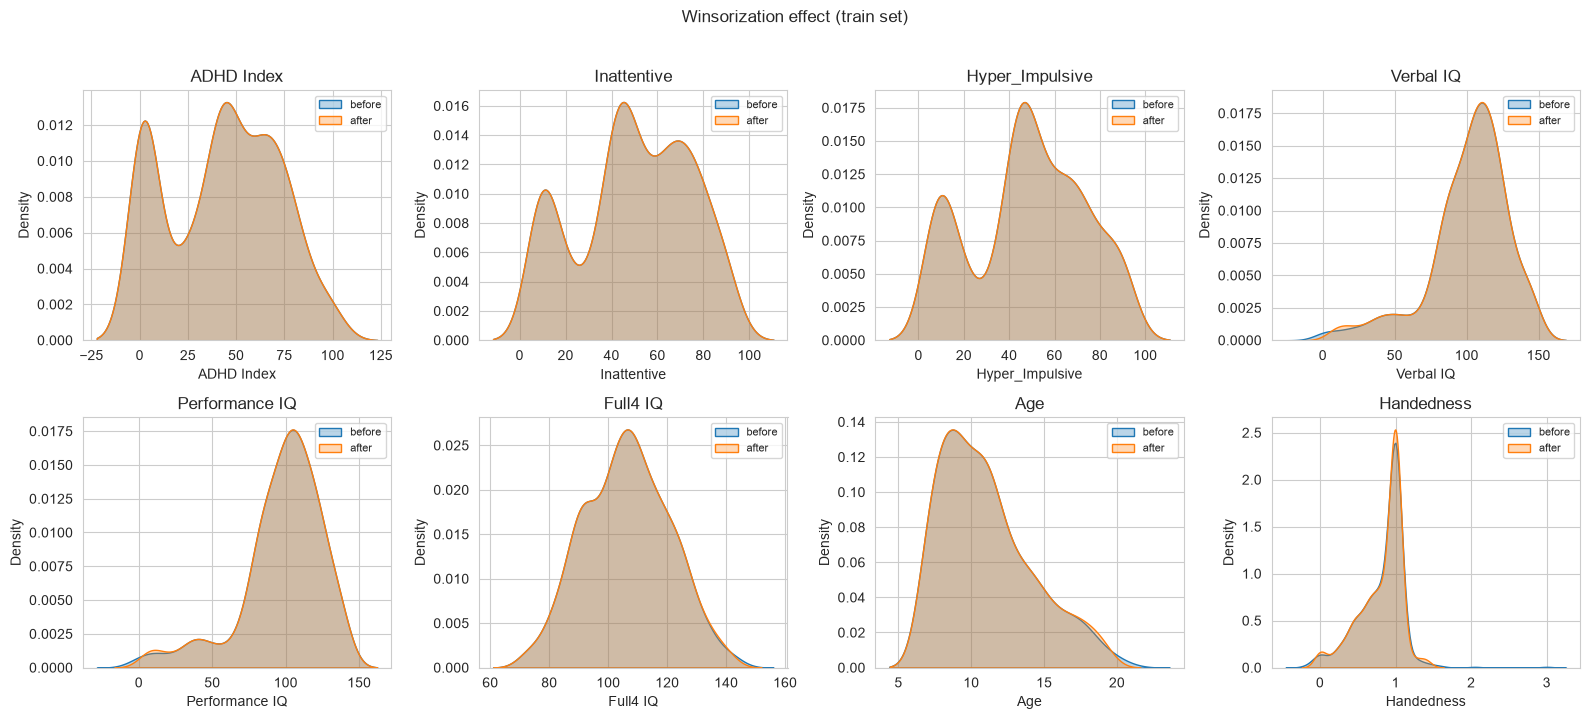

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, winsor_cols):
    sns.kdeplot(X_train[col], ax=ax, label='before', fill=True, alpha=0.3)
    sns.kdeplot(X_train_w[col], ax=ax, label='after', fill=True, alpha=0.3)
    ax.set_title(col); ax.legend(fontsize=8)
for ax in axes.flat[len(winsor_cols):]:
    ax.axis('off')
plt.suptitle('Winsorization effect (train set)', y=1.02)
plt.tight_layout(); plt.show()

## 9. Feature scaling

In [18]:
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train_w), columns=feature_cols, index=X_train_w.index)
X_test_s = pd.DataFrame(scaler.transform(X_test_w), columns=feature_cols, index=X_test_w.index)
X_train_s.describe().T[['mean', 'std']]

,mean,std
Gender,7.514200e-18,1.000847
Age,-9.618176e-17,1.000847
Handedness,-1.502840e-16,1.000847
ADHD Index,1.202272e-17,1.000847
Inattentive,-4.809088e-17,1.000847
Hyper_Impulsive,-6.011360e-18,1.000847
Verbal IQ,-3.967498e-16,1.000847
Performance IQ,-1.998777e-16,1.000847
Full4 IQ,-3.186021e-16,1.000847
Med Status,0.000000e+00,1.000847


## 10. Imbalance handling (SMOTE, training set only)

In [19]:
print('Train distribution BEFORE SMOTE:'); print(y_train.value_counts().sort_index())
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = sm.fit_resample(X_train_s, y_train)
print('\nTrain distribution AFTER SMOTE:'); print(y_train_bal.value_counts().sort_index())

Train distribution BEFORE SMOTE:
DX
0    241
1    232
2    118
Name: count, dtype: int64

Train distribution AFTER SMOTE:
DX
0    241
1    241
2    241
Name: count, dtype: int64


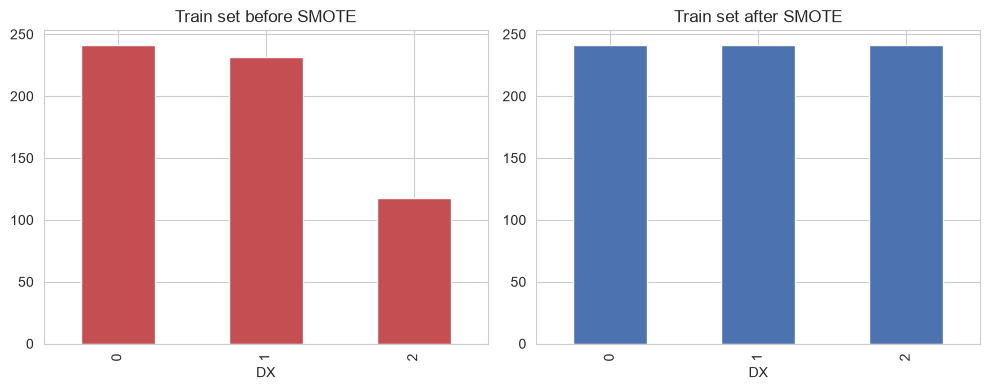

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#C44E52')
ax[0].set_title('Train set before SMOTE')
y_train_bal.value_counts().sort_index().plot(kind='bar', ax=ax[1], color='#4C72B0')
ax[1].set_title('Train set after SMOTE')
plt.tight_layout(); plt.show()

## 11. Modeling — 7 candidate classifiers

Random Forest, SVM, Logistic Regression, XGBoost, LightGBM, Gradient Boosting, KNN —
all trained on the SMOTE-balanced training set and evaluated on the held-out (untouched)
test set.

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM (RBF)': SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1),
}

results = {}
fitted_models = {}
y_test_bin = label_binarize(y_test, classes=classes)

for name, clf in models.items():
    clf.fit(X_train_bal, y_train_bal)
    fitted_models[name] = clf
    y_pred = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': roc_auc}
    print(f'{name:22s} | Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}  ROC-AUC={roc_auc:.3f}')

results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False)
best_model_name = results_df.index[0]
print(f'\nBEST BASE MODEL (by macro-F1): {best_model_name}')
results_df.round(4)

Logistic Regression    | Acc=0.777  Prec=0.767  Rec=0.780  F1=0.769  ROC-AUC=0.913
KNN                    | Acc=0.703  Prec=0.677  Rec=0.689  F1=0.670  ROC-AUC=0.870
SVM (RBF)              | Acc=0.777  Prec=0.759  Rec=0.774  F1=0.759  ROC-AUC=0.923
Random Forest          | Acc=0.824  Prec=0.809  Rec=0.819  F1=0.812  ROC-AUC=0.942
Gradient Boosting      | Acc=0.831  Prec=0.819  Rec=0.841  F1=0.820  ROC-AUC=0.954
XGBoost                | Acc=0.791  Prec=0.775  Rec=0.785  F1=0.775  ROC-AUC=0.942
LightGBM               | Acc=0.804  Prec=0.789  Rec=0.802  F1=0.792  ROC-AUC=0.944

BEST BASE MODEL (by macro-F1): Gradient Boosting


,Accuracy,Precision,Recall,F1,ROC_AUC
Gradient Boosting,0.8311,0.8185,0.8408,0.8198,0.9538
Random Forest,0.8243,0.8086,0.8192,0.8119,0.9417
LightGBM,0.8041,0.7890,0.8019,0.7916,0.9438
XGBoost,0.7905,0.7754,0.7851,0.7748,0.9419
Logistic Regression,0.7770,0.7669,0.7795,0.7694,0.9135
SVM (RBF),0.7770,0.7591,0.7738,0.7593,0.9231
KNN,0.7027,0.6767,0.6889,0.6697,0.8703


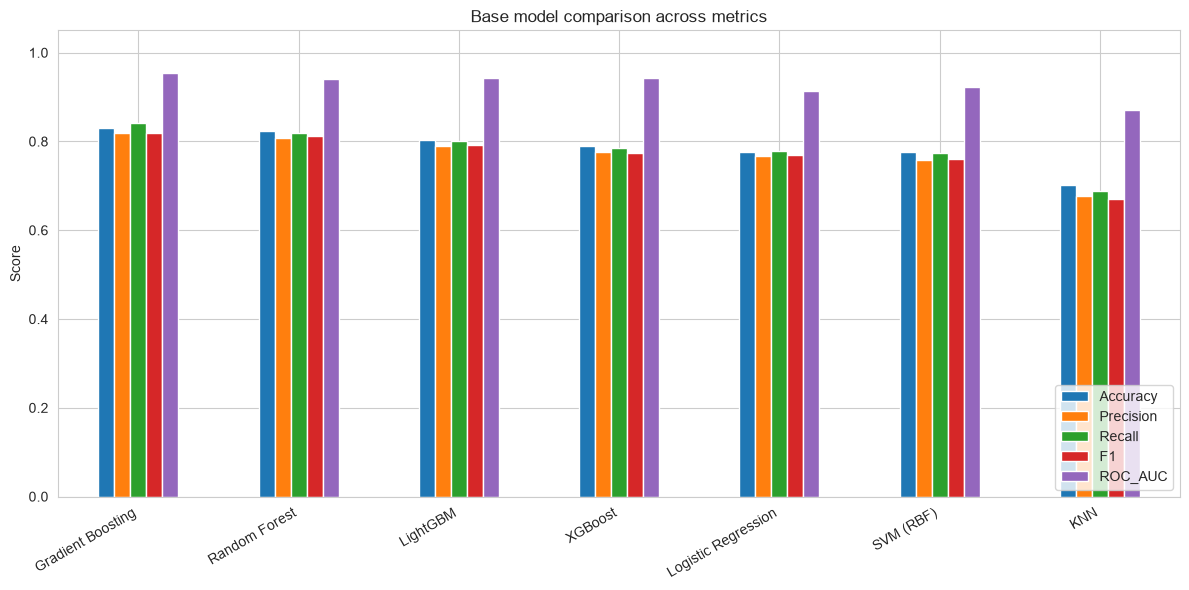

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(kind='bar', ax=ax)
ax.set_title('Base model comparison across metrics')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

### Confusion matrix — best base model

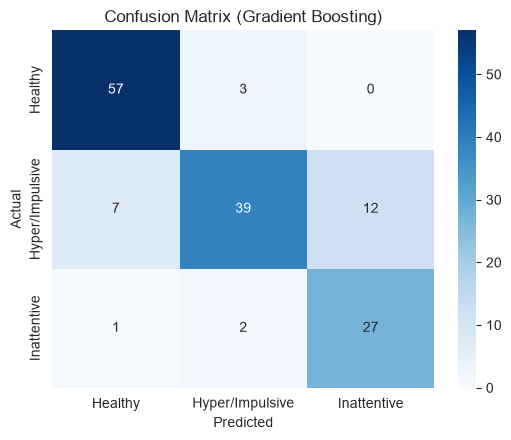

In [69]:
best_clf = fitted_models[best_model_name]
y_pred_best = best_clf.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred_best, labels=classes)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[CLASS_NAMES[c] for c in classes],
            yticklabels=[CLASS_NAMES[c] for c in classes], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix ({best_model_name})')
plt.tight_layout(); plt.show()

### ROC curves — all base models (macro-average, one-vs-rest)

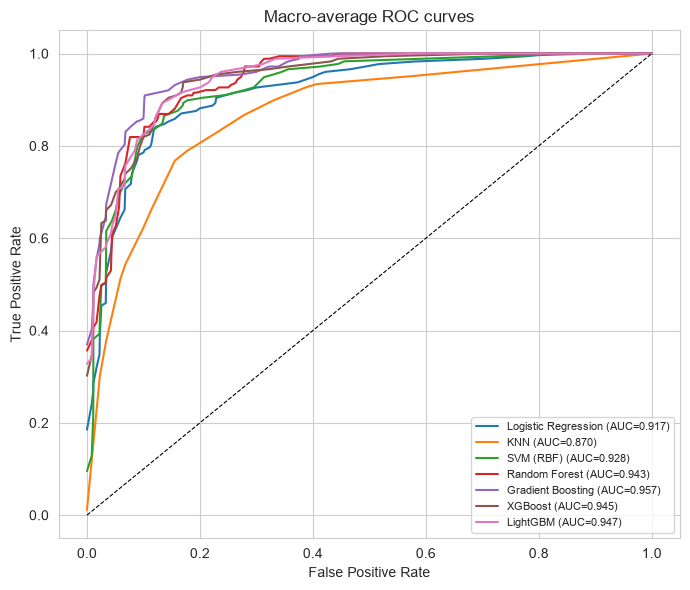

In [70]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, clf in fitted_models.items():
    y_proba = clf.predict_proba(X_test_s)
    fpr, tpr = {}, {}
    for i, c in enumerate(classes):
        fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    all_fpr = np.unique(np.concatenate([fpr[c] for c in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in classes:
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= len(classes)
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, label=f'{name} (AUC={macro_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Macro-average ROC curves')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 12. Hyperparameter tuning of the best model with metaheuristics (GWO & GA)

We tune `GradientBoostingClassifier`'s key hyperparameters
(`n_estimators`, `learning_rate`, `max_depth`, `min_samples_split`, `subsample`)
using two nature-inspired optimizers — **Grey Wolf Optimizer (GWO)** and a
**Genetic Algorithm (GA)** — with 3-fold cross-validated macro-F1 as the fitness function.

In [55]:
LB = [50, 0.01, 2, 2, 0.5]
UB = [250, 0.3, 8, 20, 1.0]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def decode(solution):
    return dict(
        n_estimators=int(round(solution[0])),
        learning_rate=float(solution[1]),
        max_depth=int(round(solution[2])),
        min_samples_split=int(round(solution[3])),
        subsample=float(solution[4]),
        random_state=RANDOM_STATE,
    )

def fitness(solution):
    params = decode(solution)
    clf = GradientBoostingClassifier(**params)
    try:
        scores = cross_val_score(clf, X_train_bal, y_train_bal, cv=cv, scoring='f1_macro', n_jobs=-1)
        score = scores.mean()
    except Exception:
        score = 0.0
    return -score

problem = {
    'obj_func': fitness,
    'bounds': FloatVar(lb=LB, ub=UB, name='gb_params'),
    'minmax': 'min',
    'log_to': None,
}

EPOCH, POP = 6, 10

In [26]:
# configs = [(10,6), (10,15), (20,10), (20,20), (30,15)]
# for pop, epoch in configs:
#     model = GWO.OriginalGWO(epoch=epoch, pop_size=pop)
#     t0 = time.time()
#     best = model.solve(problem)
#     elapsed = time.time() - t0
#     print(pop, epoch, -best.target.fitness, "time:", elapsed)

In [51]:
import numpy as np

gwo_scores = []
ga_scores = []

N_RUNS = 5

for i in range(N_RUNS):

    gwo_model = GWO.OriginalGWO(
        epoch=EPOCH,
        pop_size=POP
    )

    gwo_best = gwo_model.solve(problem)
    gwo_scores.append(-gwo_best.target.fitness)

print(f'GWO: {np.mean(gwo_scores):.2f} ± {np.std(gwo_scores):.2f}')

GWO: 0.85 ± 0.00


In [52]:
for i in range(N_RUNS):

    ga_model = GA.BaseGA(
        epoch=EPOCH,
        pop_size=POP
    )
    ga_best = ga_model.solve(problem)
    ga_scores.append(-ga_best.target.fitness)

print(f'GA : {np.mean(ga_scores):.2f} ± {np.std(ga_scores):.2f}')

GA : 0.85 ± 0.00


In [56]:
print('--- Running GWO (Grey Wolf Optimizer) ---')
t0 = time.time()
gwo_model = GWO.OriginalGWO(epoch=EPOCH, pop_size=POP)
gwo_best = gwo_model.solve(problem)
t_gwo = time.time() - t0
gwo_params = decode(gwo_best.solution)
print(f'GWO best CV macro-F1: {-gwo_best.target.fitness:.4f}  | params={gwo_params}  | time={t_gwo:.1f}s')

--- Running GWO (Grey Wolf Optimizer) ---
GWO best CV macro-F1: 0.8469  | params={'n_estimators': 60, 'learning_rate': 0.1510605036970758, 'max_depth': 7, 'min_samples_split': 14, 'subsample': 0.7585139228819772, 'random_state': 42}  | time=29.7s


In [57]:
print('--- Running GA (Genetic Algorithm) ---')
t0 = time.time()
ga_model = GA.BaseGA(epoch=EPOCH, pop_size=POP, pc=0.9, pm=0.05, selection='roulette')
ga_best = ga_model.solve(problem)
t_ga = time.time() - t0
ga_params = decode(ga_best.solution)
print(f'GA best CV macro-F1: {-ga_best.target.fitness:.4f}  | params={ga_params}  | time={t_ga:.1f}s')

--- Running GA (Genetic Algorithm) ---
GA best CV macro-F1: 0.8521  | params={'n_estimators': 88, 'learning_rate': 0.09887134668723416, 'max_depth': 5, 'min_samples_split': 4, 'subsample': 0.5895745220551408, 'random_state': 42}  | time=29.4s


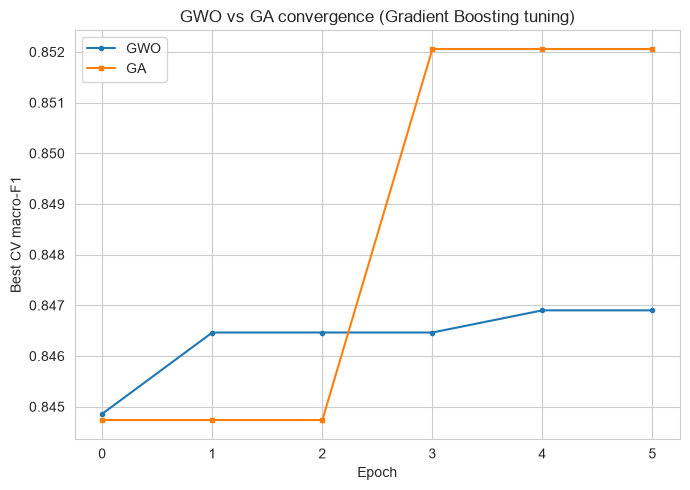

In [60]:
gwo_curve = [-f for f in gwo_model.history.list_global_best_fit]
ga_curve = [-f for f in ga_model.history.list_global_best_fit]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(gwo_curve, label='GWO', marker='o', markersize=3)
ax.plot(ga_curve, label='GA', marker='s', markersize=3)
ax.set_xlabel('Epoch'); ax.set_ylabel('Best CV macro-F1')
ax.set_title('GWO vs GA convergence (Gradient Boosting tuning)')
ax.legend()
plt.tight_layout(); plt.show()

## 13. Final comparison — baseline vs. GWO-tuned vs. GA-tuned

In [61]:
tuned_models = {
    f'{best_model_name} (baseline)': fitted_models[best_model_name],
    f'{best_model_name} + GWO': GradientBoostingClassifier(**gwo_params).fit(X_train_bal, y_train_bal),
    f'{best_model_name} + GA': GradientBoostingClassifier(**ga_params).fit(X_train_bal, y_train_bal),
}

tuned_results = {}
for name, clf in tuned_models.items():
    y_pred = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    roc_auc = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
    tuned_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC_AUC': roc_auc}
    print(f'{name:35s} | Acc={acc:.2f}  Prec={prec:.2f}  Rec={rec:.2f}  F1={f1:.2f}  ROC-AUC={roc_auc:.2f}')

tuned_df = pd.DataFrame(tuned_results).T.sort_values('F1', ascending=False)
best_tuned_name = tuned_df.index[0]
print(f'\nBEST TUNED MODEL: {best_tuned_name}')
tuned_df.round(4)

Gradient Boosting (baseline)        | Acc=0.83  Prec=0.82  Rec=0.84  F1=0.82  ROC-AUC=0.95
Gradient Boosting + GWO             | Acc=0.84  Prec=0.83  Rec=0.85  F1=0.83  ROC-AUC=0.95
Gradient Boosting + GA              | Acc=0.84  Prec=0.84  Rec=0.85  F1=0.84  ROC-AUC=0.96

BEST TUNED MODEL: Gradient Boosting + GA


,Accuracy,Precision,Recall,F1,ROC_AUC
Gradient Boosting + GA,0.8446,0.8380,0.8471,0.8393,0.9551
Gradient Boosting + GWO,0.8378,0.8264,0.8467,0.8317,0.9517
Gradient Boosting (baseline),0.8311,0.8185,0.8408,0.8198,0.9538


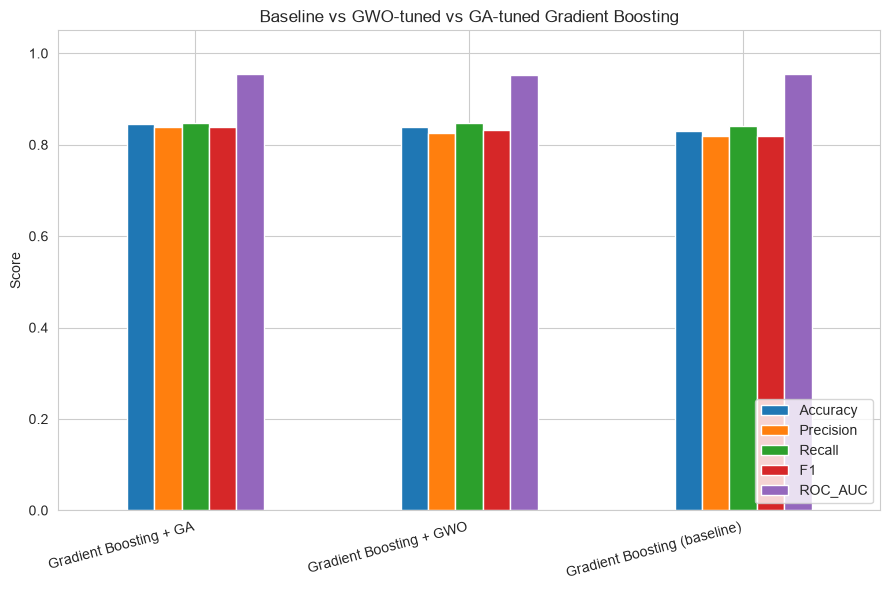

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
tuned_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(kind='bar', ax=ax)
ax.set_title('Baseline vs GWO-tuned vs GA-tuned Gradient Boosting')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

### Confusion matrix — best tuned model

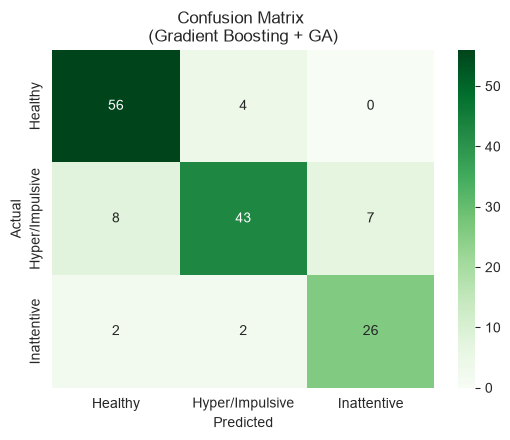

In [71]:
best_tuned_clf = tuned_models[best_tuned_name]
y_pred_best_tuned = best_tuned_clf.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred_best_tuned, labels=classes)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[CLASS_NAMES[c] for c in classes],
            yticklabels=[CLASS_NAMES[c] for c in classes], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix \n({best_tuned_name})')
plt.tight_layout(); plt.show()

### ROC curves — tuned models (macro-average, one-vs-rest)

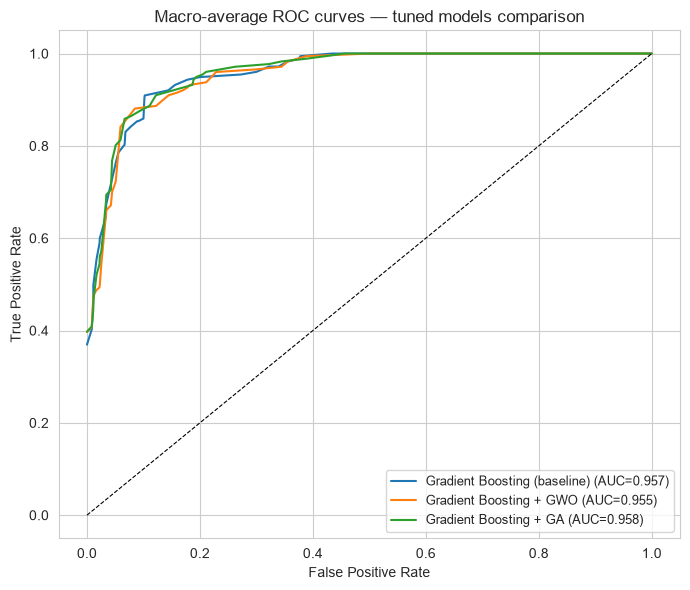

In [72]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, clf in tuned_models.items():
    y_proba = clf.predict_proba(X_test_s)
    fpr, tpr = {}, {}
    for i, c in enumerate(classes):
        fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    all_fpr = np.unique(np.concatenate([fpr[c] for c in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in classes:
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= len(classes)
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, label=f'{name} (AUC={macro_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('Macro-average ROC curves — tuned models comparison')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

In [74]:
import shap

print(f"Running SHAP for best tuned model: {best_tuned_name}")

# GradientBoostingClassifier's multiclass form isn't supported by shap.TreeExplainer,
# so we use the model-agnostic Explainer (permutation-based) on predict_proba instead.
# Use a background sample to keep it fast.
background = shap.sample(X_train_bal, 100, random_state=RANDOM_STATE)

explainer = shap.Explainer(best_tuned_clf.predict_proba, background)
shap_values = explainer(X_test_s)

print(type(shap_values), shap_values.values.shape)  # (n_samples, n_features, n_classes)

Running SHAP for best tuned model: Gradient Boosting + GA


ExactExplainer explainer: 149it [00:27,  3.92it/s]                         

<class 'shap._explanation.Explanation'> (148, 10, 3)



SHAP summary — class 0 (Healthy)


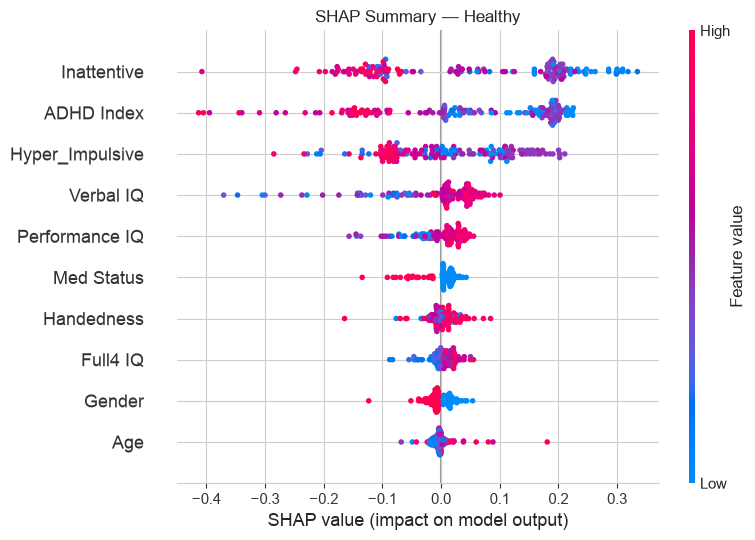


SHAP summary — class 1 (Hyper/Impulsive)


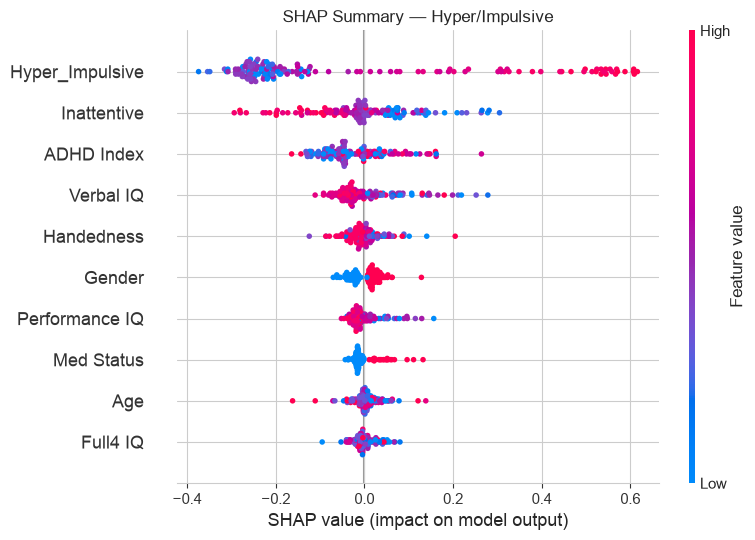


SHAP summary — class 2 (Inattentive)


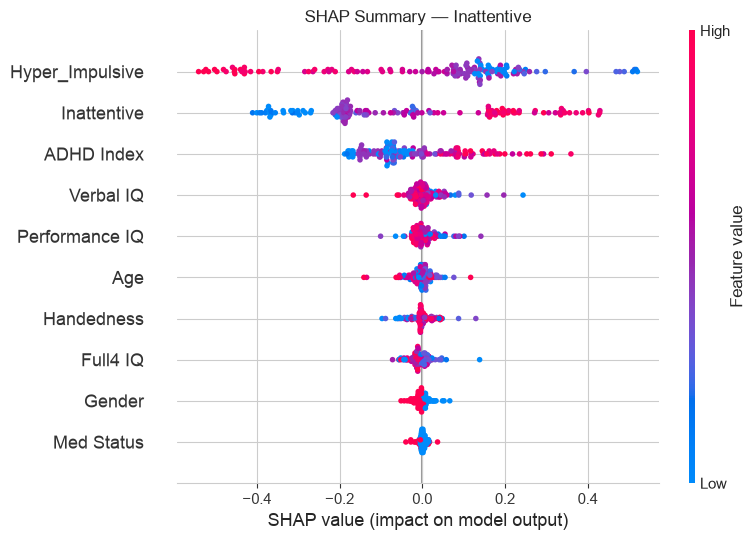

In [75]:
for i, c in enumerate(classes):
    print(f"\nSHAP summary — class {c} ({CLASS_NAMES[c]})")
    plt.figure(figsize=(8, 5))
    shap.summary_plot(shap_values.values[:, :, i], X_test_s, show=False)
    plt.title(f'SHAP Summary — {CLASS_NAMES[c]}')
    plt.tight_layout()
    plt.show()

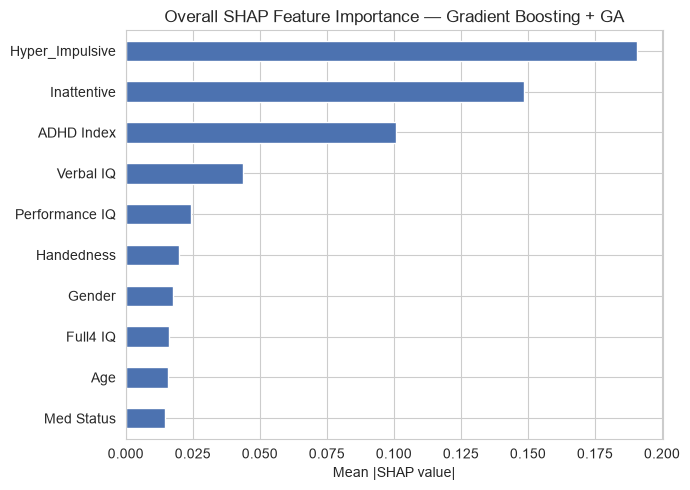

Hyper_Impulsive    0.190733
Inattentive        0.148382
ADHD Index         0.100934
Verbal IQ          0.043899
Performance IQ     0.024306
Handedness         0.020000
Gender             0.017552
Full4 IQ           0.016297
Age                0.015795
Med Status         0.014521
dtype: float64

In [76]:
mean_abs = np.abs(shap_values.values).mean(axis=(0, 2))

shap_importance = pd.Series(mean_abs, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
shap_importance.plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_title(f'Overall SHAP Feature Importance — {best_tuned_name}')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()

shap_importance

Explaining test sample 0 — predicted class: Hyper/Impulsive


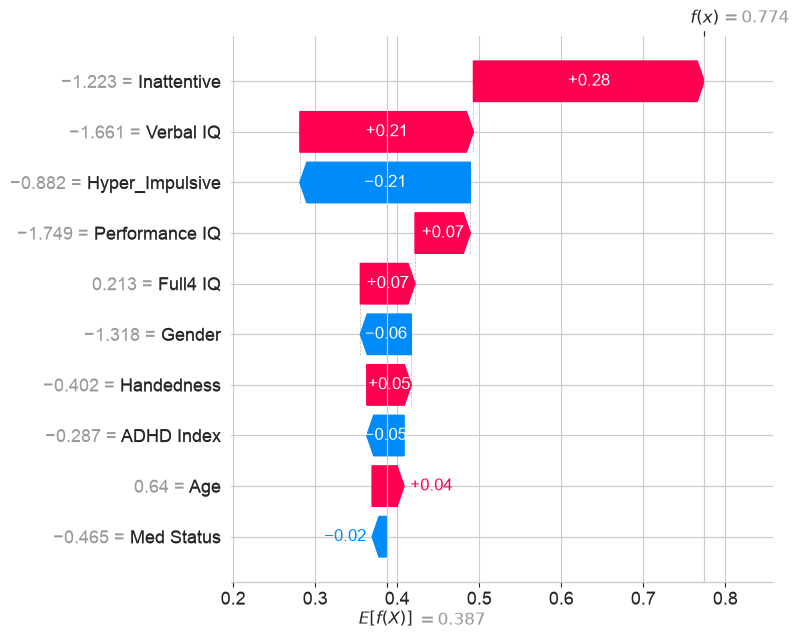

In [77]:
sample_idx = 0
pred_class = best_tuned_clf.predict(X_test_s.iloc[[sample_idx]])[0]
class_idx = list(classes).index(pred_class)

print(f"Explaining test sample {sample_idx} — predicted class: {CLASS_NAMES[pred_class]}")

sv_single = shap.Explanation(
    values=shap_values.values[sample_idx, :, class_idx],
    base_values=shap_values.base_values[sample_idx, class_idx],
    data=X_test_s.iloc[sample_idx].values,
    feature_names=feature_cols
)

shap.waterfall_plot(sv_single, show=False)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

CLASS_NAMES = {0: 'Healthy', 1: 'Hyper/Impulsive', 2: 'Inattentive'}

model_bundle = {
    'model': best_tuned_clf,
    'scaler': scaler,
    'winsor_bounds': bounds,
    'feature_cols': feature_cols,
    'classes': classes,
    'class_names': CLASS_NAMES,
    'best_tuned_name': best_tuned_name,
}

FOLDER_NAME = 'models'
FILE_NAME = 'adhd_model_bundle.joblib'
joblib.dump(model_bundle, f'{FOLDER_NAME}/{FILE_NAME}')
print(f"Saved model bundle -> {FOLDER_NAME}/{FILE_NAME}")
print(f"Model: {best_tuned_name}")
print(f"Features expected (in order): {feature_cols}")

Saved model bundle -> models/adhd_model_bundle.joblib
Model: Gradient Boosting + GA
Features expected (in order): ['Gender', 'Age', 'Handedness', 'ADHD Index', 'Inattentive', 'Hyper_Impulsive', 'Verbal IQ', 'Performance IQ', 'Full4 IQ', 'Med Status']


In [81]:
FOLDER_NAME = 'models'
FILE_NAME = 'adhd_model_bundle.joblib'

loaded_bundle = joblib.load(f'{FOLDER_NAME}/{FILE_NAME}')
loaded_model = loaded_bundle['model']
loaded_scaler = loaded_bundle['scaler']
loaded_bounds = loaded_bundle['winsor_bounds']
loaded_features = loaded_bundle['feature_cols']
loaded_classes = loaded_bundle['classes']
loaded_class_names = loaded_bundle['class_names']

print("Reloaded model:", type(loaded_model).__name__)
print("Expected feature order:", loaded_features)

Reloaded model: GradientBoostingClassifier
Expected feature order: ['Gender', 'Age', 'Handedness', 'ADHD Index', 'Inattentive', 'Hyper_Impulsive', 'Verbal IQ', 'Performance IQ', 'Full4 IQ', 'Med Status']


In [82]:
def predict_new_subject(raw_input: dict, bundle):
    """
    raw_input: dict with RAW (unscaled) values for these keys:
      'Gender', 'Age', 'Handedness', 'ADHD Index', 'Inattentive', 'Hyper_Impulsive',
      'Verbal IQ', 'Performance IQ', 'Full4 IQ', 'Med Status'
    Applies the SAME preprocessing pipeline as training: winsorize -> scale -> predict.
    """
    feats = bundle['feature_cols']
    df_new = pd.DataFrame([raw_input])[feats]

    # 1) winsorize using saved train-set bounds
    for col, (lo, hi) in bundle['winsor_bounds'].items():
        if col in df_new.columns:
            df_new[col] = df_new[col].clip(lower=lo, upper=hi)

    # 2) scale using saved scaler
    X_new_s = pd.DataFrame(bundle['scaler'].transform(df_new), columns=feats)

    # 3) predict
    pred = bundle['model'].predict(X_new_s)[0]
    proba = bundle['model'].predict_proba(X_new_s)[0]

    print(f"Predicted class: {pred} -> {bundle['class_names'][pred]}")
    print("Class probabilities:")
    for c, p in zip(bundle['classes'], proba):
        print(f"  {bundle['class_names'][c]:12s}: {p:.3f}")
    return pred, proba


# Example: edit these values to test different subjects
example_subject = {
    'Gender': 1,          # e.g. 0=Female, 1=Male (check your original coding)
    'Age': 11.5,
    'Handedness': 1.0,
    'ADHD Index': 65.0,
    'Inattentive': 60.0,
    'Hyper_Impulsive': 58.0,
    'Verbal IQ': 105.0,
    'Performance IQ': 100.0,
    'Full4 IQ': 103.0,
    'Med Status': 0,      # e.g. 0=not medicated, 1=medicated
}

predict_new_subject(example_subject, loaded_bundle)

Predicted class: 1 -> Hyper/Impulsive
Class probabilities:
  Healthy     : 0.010
  Hyper/Impulsive: 0.784
  Inattentive : 0.206


(1, array([0.01012643, 0.78425541, 0.20561816]))